In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#### experiments with derivatives
Derivative defines, how a function changes if we add a small change to the input point(x in this case), whether the value of the function goes up or down and by how much it changes.

In [2]:
# random function
def f(x):
    out = 3 * x**2 + 4*x + 2
    return out

In [3]:
f(5) #sample output

97

In [4]:
xs = np.arange(-5,5, 0.25)
ys = f(xs)
ys # sample output values from the function

array([57.    , 50.6875, 44.75  , 39.1875, 34.    , 29.1875, 24.75  ,
       20.6875, 17.    , 13.6875, 10.75  ,  8.1875,  6.    ,  4.1875,
        2.75  ,  1.6875,  1.    ,  0.6875,  0.75  ,  1.1875,  2.    ,
        3.1875,  4.75  ,  6.6875,  9.    , 11.6875, 14.75  , 18.1875,
       22.    , 26.1875, 30.75  , 35.6875, 41.    , 46.6875, 52.75  ,
       59.1875, 66.    , 73.1875, 80.75  , 88.6875])

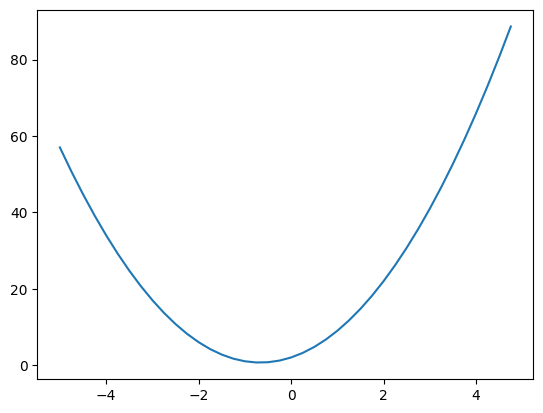

In [5]:
# plot the function
plt.plot(xs,ys)

In [6]:
h = 0.000000000000001 # the small change
x = -5
dydx = (f(x + h) - f(x)) / h
dydx

-28.421709430404004

Partial Derivatives

In [7]:
h = 0.00001
a = 2.0
b = -3.0
c = 10.0
d = a*b + c

#derivative with respect to a
d1 = a * b + c
a += h 
d2 = a * b + c
print("d1", d1)
print("d2", d2)
print("slope with respect to a : ",(d2 - d1)/h)

#derivative with respect to b
d1 = a * b + c
b += h
d2 = a * b + c
print("\nd1", d1)
print("d2", d2)
print("slope with respect to b : ",(d2 - d1)/h)

#derivative with respect to c
d1 = a * b + c
c += h
d2 = a * b + c
print("\nd1", d1)
print("d2", d2)
print("slope with respect to c : ",(d2 - d1)/h)

d1 4.0
d2 3.9999699999999994
slope with respect to a :  -3.000000000064062

d1 3.9999699999999994
d2 3.9999900000999995
slope with respect to b :  2.00001000001393

d1 3.9999900000999995
d2 4.000000000099999
slope with respect to c :  0.9999999999621422


#### Creating the Value Class

In [73]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad = 0 
        self._backward = lambda: None
        self._prev = set(_children) # keeps track of the value objects that led to the new value object
        self._op = _op  # keeps track of the operator that led to the value object
        self.label = label 
        
    def __repr__(self):
        return f"ValueData=({self.data}, label=({self.label}), gradient = ({self.grad}), backprop = ({self._backward}))"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out
    def __radd__(self, other):
        return self + other
        
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
        
    def __rmul__(self, other):
        return  self*other
      

    def __truediv__(self, other):
        return self * (other**-1)
        # a / b, a*(b**-1)
        # value(a) * (value(b) ** -1)
        
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data**other, (self, ) , f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other - 1)) * out.grad
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x),(self, ),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        n = self.data
        th = (math.exp(2*n) - 1)/(math.exp(2*n) + 1 )
        out = Value(th, (self, ), 'tanh')

        def _backward():
            self.grad = (1-th**2) * out.grad
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [87]:
a = Value(2, label = "pow a")
a

ValueData=(2, label=(pow a), gradient = (0), backprop = (<function Value.__init__.<locals>.<lambda> at 0x0000025BE70C8040>))

In [94]:
b = a**3 ;b.label = 'a'
b

ValueData=(8, label=(a), gradient = (0), backprop = (<function Value.__pow__.<locals>._backward at 0x0000025BE70C81F0>))

In [9]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b ; e.label = 'e'
d = e + c ; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d*f ; L.label = 'L'
L

ValueData=(-8.0, label=(L), gradient = (0), backprop = (<function Value.__mul__.<locals>._backward at 0x0000025BE3AAF400>))

In [10]:
d._prev

{ValueData=(-6.0, label=(e), gradient = (0), backprop = (<function Value.__mul__.<locals>._backward at 0x0000025BE3AAF2E0>)),
 ValueData=(10.0, label=(c), gradient = (0), backprop = (<function Value.__init__.<locals>.<lambda> at 0x0000025BE3AAF1C0>))}

In [11]:
d._op

'+'

In [12]:
import sys

In [13]:
sys.getrefcount(d)

5

#### Graphviz visualization

In [14]:
from graphviz import Digraph

In [15]:
def trace(root):
    # build the set of all the nodes and edges in a graph
    nodes , edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
            
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr={'rankdir': 'LR'})

    nodes , edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph we create a rectangular node
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if the value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # connect the node to iit
            dot.edge(uid+n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

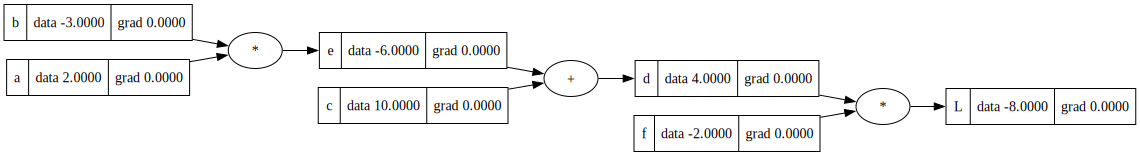

In [16]:
draw_dot(L)

In [17]:
def lol():
    h = 0.0001
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d*f ; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label = 'c')
    e = a*b ; e.label = 'e'
    d = e + c ; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d*f ; L.label = 'L'
    L2 = L.data + h

    print((L2-L1)/h)
lol()

0.9999999999976694


In [18]:
L.grad = 1
d.grad = f.data
f.grad = d.data
e.grad = f.data
c.grad = f.data
b.grad = a.data * e.grad
a.grad = b.data * e.grad

In [19]:
# finding gradients
"""
L = d * f
dL/dd = f

dL/dd = ((d+h)*f - d*f)/h
      = (df + hf - df)/h
      = hf/f
      = f
      
therefore d.grad = f.data

dL/df = d 

dL/de = ?
d = e + c
dd/de = 1
dd/dc = 1

dL/de = dL/dd * dd/de
      = f * 1 = f

dL/dc = dL/dd * dd/dc
      = f * 1 = f
e = a * b
de/da = b
de/db = a

dL/da = dL/de * de/da
      = f * b
dL/db = dL/de * de/db
      = f * a
"""

'\nL = d * f\ndL/dd = f\n\ndL/dd = ((d+h)*f - d*f)/h\n      = (df + hf - df)/h\n      = hf/f\n      = f\n      \ntherefore d.grad = f.data\n\ndL/df = d \n\ndL/de = ?\nd = e + c\ndd/de = 1\ndd/dc = 1\n\ndL/de = dL/dd * dd/de\n      = f * 1 = f\n\ndL/dc = dL/dd * dd/dc\n      = f * 1 = f\ne = a * b\nde/da = b\nde/db = a\n\ndL/da = dL/de * de/da\n      = f * b\ndL/db = dL/de * de/db\n      = f * a\n'

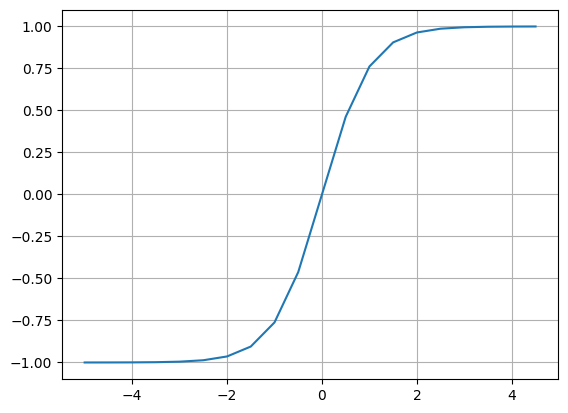

In [20]:
plt.plot(np.arange(-5,5,.5), np.tanh(np.arange(-5,5,0.5)))
plt.grid()

In [31]:
# these are two inputs x1, and x2 , we are creating a 2 dimensional nueron
x1 = Value(2.0, label ='x1')
x2 = Value(0.0, label = 'x2')

# weights w1 and w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')

# the bias of the neuron
b = Value(6.8813735870195432, label = 'b')
#x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1w1'
x2w2 = x2*w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b ; n.label = 'n'

#we have to implement tanh
o = n.tanh() ; o.label = 'o'

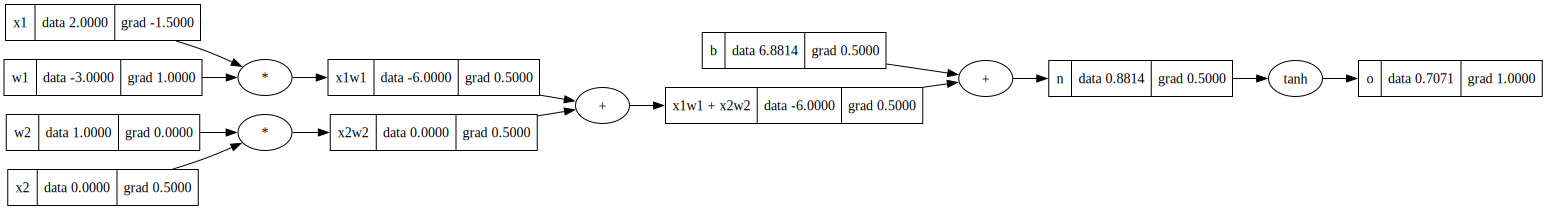

In [36]:
draw_dot(o)

In [23]:
#do/do = 1
o.grad = 1.0

#do/dn = d(tahn(o))/dn 
# 1- tanh(n)**2, tanh(n) = o
n.grad = 1 - o.data**2

x1w1x2w2.grad = n.grad
b.grad = n.grad

x1w1.grad = x1w1x2w2.grad
x2w2.grad = x1w1x2w2.grad

w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad

w2.grad = x2.data * x2w2.grad
x2.grad = w2.data * x2w2.grad

In [24]:
# topological sort
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo

[ValueData=(-3.0, label=(w1), gradient = (0.9999999999999998), backprop = (<function Value.__init__.<locals>.<lambda> at 0x0000025BE3B53B50>)),
 ValueData=(2.0, label=(x1), gradient = (-1.4999999999999996), backprop = (<function Value.__init__.<locals>.<lambda> at 0x0000025BE3B53D90>)),
 ValueData=(-6.0, label=(x1w1), gradient = (0.4999999999999999), backprop = (<function Value.__mul__.<locals>._backward at 0x0000025BE3BC81F0>)),
 ValueData=(0.0, label=(x2), gradient = (0.4999999999999999), backprop = (<function Value.__init__.<locals>.<lambda> at 0x0000025BE3B53BE0>)),
 ValueData=(1.0, label=(w2), gradient = (0.0), backprop = (<function Value.__init__.<locals>.<lambda> at 0x0000025BE3BC8040>)),
 ValueData=(0.0, label=(x2w2), gradient = (0.4999999999999999), backprop = (<function Value.__mul__.<locals>._backward at 0x0000025BE3BC8280>)),
 ValueData=(-6.0, label=(x1w1 + x2w2), gradient = (0.4999999999999999), backprop = (<function Value.__add__.<locals>._backward at 0x0000025BE3BC8310>)

In [33]:
o.grad = 1.0
for n in reversed(topo):
    n._backward()

In [35]:
o.backward()

In [27]:
a = Value(3.0, label = 'a')
b = a + a
b.backward()

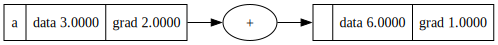

In [28]:
draw_dot(b) # this gives us a wrong grad , we need to fix the value class by using incrementing for the grands and not assignments


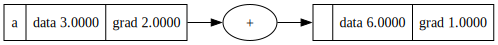

In [29]:
a = Value(3.0, label = 'a')
b = a + a
b.backward()
draw_dot(b)

In [58]:
a = Value(1)

In [59]:
a + 1

ValueData=(2, label=(), gradient = (0), backprop = (<function Value.__add__.<locals>._backward at 0x0000025BE70ADB40>))

In [60]:
1 + a

ValueData=(2, label=(), gradient = (0), backprop = (<function Value.__add__.<locals>._backward at 0x0000025BE70AD5A0>))

In [61]:
a * 2

ValueData=(2, label=(), gradient = (0), backprop = (<function Value.__mul__.<locals>._backward at 0x0000025BE70ADA20>))